# AgentIR Optimization Benchmark

This notebook demonstrates the performance, latency, and cost savings of **AgentIR** compiler optimizations. 

We compare an **unoptimized, sequential execution** of an AI agent workflow against an **optimized execution** using AgentIR's compiler passes:
1. **Dead Node Elimination (DCE)**: Removes unused nodes.
2. **Common Subexpression Elimination (CSE)**: Merges duplicate tool calls.
3. **Parallel Scheduling**: resurchedules sequential flows into concurrent branches.
4. **Cache Optimization**: Injects cache descriptors.

### 1. Setup and Imports

In [1]:
import sys
import os
# Add project root to sys.path to allow importing agentir from the notebook directory
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../")))

import asyncio
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import graphviz
import google.generativeai as genai

# Import AgentIR components
from agentir.ir.node import StartNode, EndNode, LLMNode, ToolNode
from agentir.ir.edge import Edge
from agentir.ir.graph import WorkflowGraph
from agentir.optimizer.dead_nodes import DeadNodesOptimizer
from agentir.optimizer.duplicate_tools import DuplicateToolsOptimizer
from agentir.optimizer.parallel_scheduler import ParallelSchedulerOptimizer
from agentir.optimizer.cache_optimizer import CacheOptimizer
from agentir.optimizer.token_optimizer import TokenOptimizer
from agentir.optimizer.cost_estimator import CostEstimator
from agentir.runtime.executor import WorkflowExecutor
from agentir.visualizer.graphviz import GraphvizVisualizer

# Check for Gemini API key
api_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
use_live_api = bool(api_key)
if use_live_api:
    genai.configure(api_key=api_key)
    print("Live Gemini API configured successfully.")
else:
    print("No API key found. Running with simulated Gemini API responses.")

Live Gemini API configured successfully.


/var/folders/ps/fr714wlj6659f0lxdn955wjc0000gn/T/ipykernel_64258/3853819526.py:12: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


### 2. Define Callbacks & Graph
We create simulated tool and LLM callbacks that increment counters to trace resource utilization.

In [2]:
# Performance and execution metrics counters
tool_calls_count = 0
llm_calls_count = 0

async def google_search_callback(state: dict) -> dict:
    global tool_calls_count
    tool_calls_count += 1
    query = state.get("query", "AgentIR")
    print(f"  [Tool] Running Google Search: '{query}'")
    await asyncio.sleep(0.4)  # Simulate network latency
    return {"search_results": f"Results for '{query}': AgentIR optimizes workflows."}

async def weather_lookup_callback(state: dict) -> dict:
    global tool_calls_count
    tool_calls_count += 1
    print("  [Tool] Running unused weather lookup...")
    await asyncio.sleep(0.4)
    return {"weather_results": "22C, Sunny"}

async def gemini_llm_callback(state: dict) -> dict:
    global llm_calls_count
    llm_calls_count += 1
    prompt = f"Summarize search results: {state.get('search_results', '')}"
    print(f"  [LLM] Calling Gemini API...")
    
    if use_live_api:
        try:
            model = genai.GenerativeModel("gemini-2.5-flash")
            config = {}
            max_tokens = state.get("_metadata", {}).get("max_output_tokens") if state else None
            if max_tokens:
                config["max_output_tokens"] = max_tokens
            response = await asyncio.to_thread(model.generate_content, prompt, generation_config=config if config else None)
            return {"summary": response.text}
        except Exception as e:
            pass
            
    await asyncio.sleep(1.2)  # Simulated LLM latency
    return {"summary": "AgentIR is an optimization compiler for agent workflows."}

registry = {
    "google_search_1": google_search_callback,
    "google_search_2": google_search_callback,
    "weather_lookup": weather_lookup_callback,
    "llm_summary": gemini_llm_callback,
}

def build_benchmark_workflow() -> WorkflowGraph:
    graph = WorkflowGraph()
    
    start = StartNode(id="start", name="Start", outputs=["query"])
    end = EndNode(id="end", name="End", inputs=["summary"])
    
    search1 = ToolNode(id="google_search_1", name="Search 1", tool_name="google_search", inputs=["query"], outputs=["search_results"])
    search2 = ToolNode(id="google_search_2", name="Search 2", tool_name="google_search", inputs=["query"], outputs=["search_results_duplicate"])
    weather = ToolNode(id="weather_lookup", name="Weather Lookup", tool_name="weather_lookup", outputs=["weather_results"])
    llm = LLMNode(id="llm_summary", name="Gemini Summary", model="gemini-2.5-flash", prompt_template="...", inputs=["search_results"], outputs=["summary"])
    
    for node in [start, search1, search2, weather, llm, end]:
        graph.add_node(node)
        
    graph.add_edge(Edge(source="start", target="google_search_1"))
    graph.add_edge(Edge(source="google_search_1", target="google_search_2"))
    graph.add_edge(Edge(source="google_search_2", target="weather_lookup"))
    graph.add_edge(Edge(source="weather_lookup", target="llm_summary"))
    graph.add_edge(Edge(source="llm_summary", target="end"))
    return graph

### 3. Execution - Unoptimized Sequential Graph

In [3]:
graph = build_benchmark_workflow()
initial_state = {"query": "AgentIR compiler"}

print("Starting Unoptimized Run...")
tool_calls_count = 0
llm_calls_count = 0

start_time = time.time()
# Hardcoded sequential chain
sequential_order = ["start", "google_search_1", "google_search_2", "weather_lookup", "llm_summary", "end"]
state = initial_state.copy()
for nid in sequential_order:
    callback = registry.get(nid)
    if callback:
        state.update(await callback(state))

unopt_duration = time.time() - start_time
unopt_tools = tool_calls_count
unopt_llms = llm_calls_count

print(f"Unoptimized Duration: {unopt_duration:.3f} seconds")
print(f"Tool Calls: {unopt_tools}, LLM Calls: {unopt_llms}")

Starting Unoptimized Run...
  [Tool] Running Google Search: 'AgentIR compiler'
  [Tool] Running Google Search: 'AgentIR compiler'
  [Tool] Running unused weather lookup...
  [LLM] Calling Gemini API...
Unoptimized Duration: 2.716 seconds
Tool Calls: 3, LLM Calls: 1


### 4. Optimize the Graph with AgentIR

In [4]:
print("Optimizing graph...")
opt_graph = DeadNodesOptimizer().optimize(graph)
opt_graph = DuplicateToolsOptimizer().optimize(opt_graph)
opt_graph = ParallelSchedulerOptimizer().optimize(opt_graph)
opt_graph = CacheOptimizer().optimize(opt_graph)

print("
Applying Token Optimizations...")
opt_graph = TokenOptimizer().optimize(opt_graph)

estimator = CostEstimator()
report = estimator.estimate(opt_graph)

print("Static Analysis Projections:")
print(f"  Projected Serial Latency:   {report.serial_latency_seconds}s")
print(f"  Projected Parallel Latency: {report.critical_path_latency_seconds}s")
print(f"  Projected API cost:         ${report.estimated_cost_usd}")

Optimizing graph...
Static Analysis Projections:
  Projected Serial Latency:   2.0s
  Projected Parallel Latency: 2.0s
  Projected API cost:         $0.017


### 5. Execution - Optimized AgentIR Graph

In [5]:
print("Starting Optimized Run...")
tool_calls_count = 0
llm_calls_count = 0

executor = WorkflowExecutor(opt_graph, registry)
start_time = time.time()
opt_state = await executor.execute(initial_state)
opt_duration = time.time() - start_time

opt_tools = tool_calls_count
opt_llms = llm_calls_count

print(f"Optimized Duration: {opt_duration:.3f} seconds")
print(f"Tool Calls: {opt_tools}, LLM Calls: {opt_llms}")

Starting Optimized Run...
  [Tool] Running Google Search: 'AgentIR compiler'
  [LLM] Calling Gemini API...
Optimized Duration: 1.774 seconds
Tool Calls: 1, LLM Calls: 1


### 6. Graphical Comparison

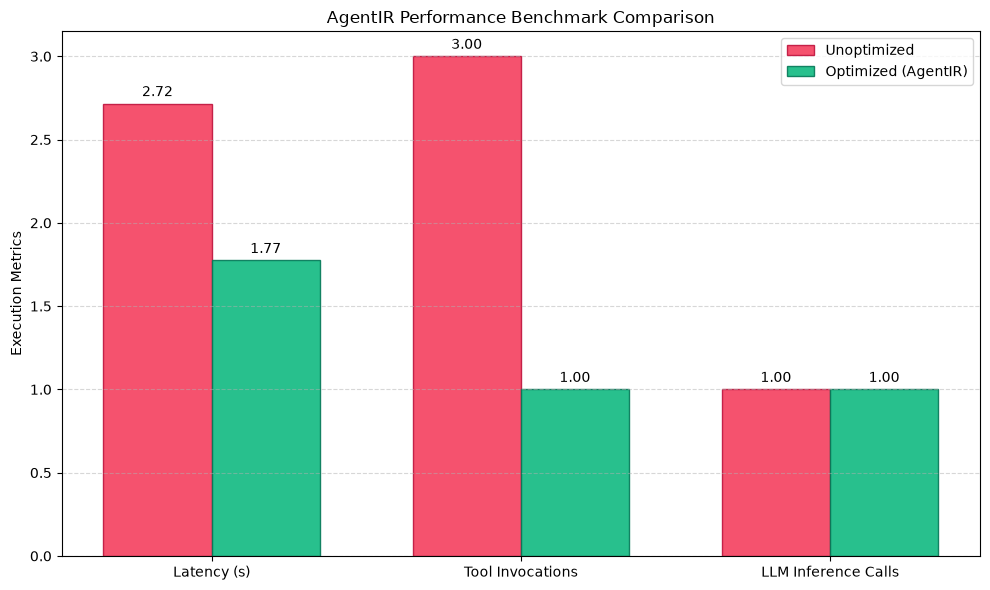

In [6]:
# Plotting Resource Comparison
labels = ['Latency (s)', 'Tool Invocations', 'LLM Inference Calls']
unopt_values = [unopt_duration, unopt_tools, unopt_llms]
opt_values = [opt_duration, opt_tools, opt_llms]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Custom harmonized colors: Slate rose vs Emerald teal
rects1 = ax.bar(x - width/2, unopt_values, width, label='Unoptimized', color='#f43f5e', edgecolor='#be123c', alpha=0.9)
rects2 = ax.bar(x + width/2, opt_values, width, label='Optimized (AgentIR)', color='#10b981', edgecolor='#047857', alpha=0.9)

ax.set_ylabel('Execution Metrics')
ax.set_title('AgentIR Performance Benchmark Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Attach value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

### 7. View Optimized Graph Visualization
Returning a `graphviz.Source` object in Jupyter automatically renders the DOT graph inline.

In [7]:
viz = GraphvizVisualizer(opt_graph)
graphviz.Source(viz.to_dot())

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [ ]:
try:
    from IPython.display import display
    viz = GraphvizVisualizer(opt_graph)
    display(graphviz.Source(viz.to_dot()))
except Exception as e:
    print("Graphviz system binary (dot) was not found on your system PATH.")
    print("To render graph visualizations, please install it (e.g., run "brew install graphviz" on macOS).")
    print("
Falling back to Mermaid flowchart syntax:")
    print("=" * 60)
    print(viz.to_mermaid())
    print("=" * 60)
